# 04 — Speed-Efficiency Map & Fleet Fuel Consumption
## Vehicle Telematics Project

**What this notebook does:**
- Speed-efficiency map per vehicle (12 speed zones, 0–150 km/h)
- Fleet-wide heatmap — all vehicles vs all speed zones
- Trip-level fuel consumption calculation (speed × time integration)
- Fleet summary — total distance, fuel, efficiency per vehicle

**Key finding:** Fleet optimal speed zone is 60–90 km/h.

**Requires:** Run `01_data_cleaning.ipynb` first.

**Author:** Paşan Sancak · [LinkedIn](https://linkedin.com/in/pasansancak) · [GitHub](https://github.com/pasansancak)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, json
sys.path.append('..')
from src.features import add_speed_zone
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style='darkgrid', palette='muted')

df       = pd.read_parquet('../data/processed/clean.parquet')
EXCLUDED = json.load(open('../data/processed/excluded_devices.json'))

df_moving = df[
    (df['speed'] > 2) &
    (df['kpl'] > 0) &
    (~df['deviceID'].isin(EXCLUDED))
].copy()

df_moving = add_speed_zone(df_moving, ordinal=False)

print(f'Loaded    : {len(df):,} rows')
print(f'Moving    : {len(df_moving):,} rows')
print(f'Excluded  : {[int(d) for d in EXCLUDED]}')

Loaded    : 3,021,632 rows
Moving    : 1,582,926 rows
Excluded  : [0, 1, 2, 4, 11, 14, 7]


## 1. Speed-Efficiency Map (per vehicle)

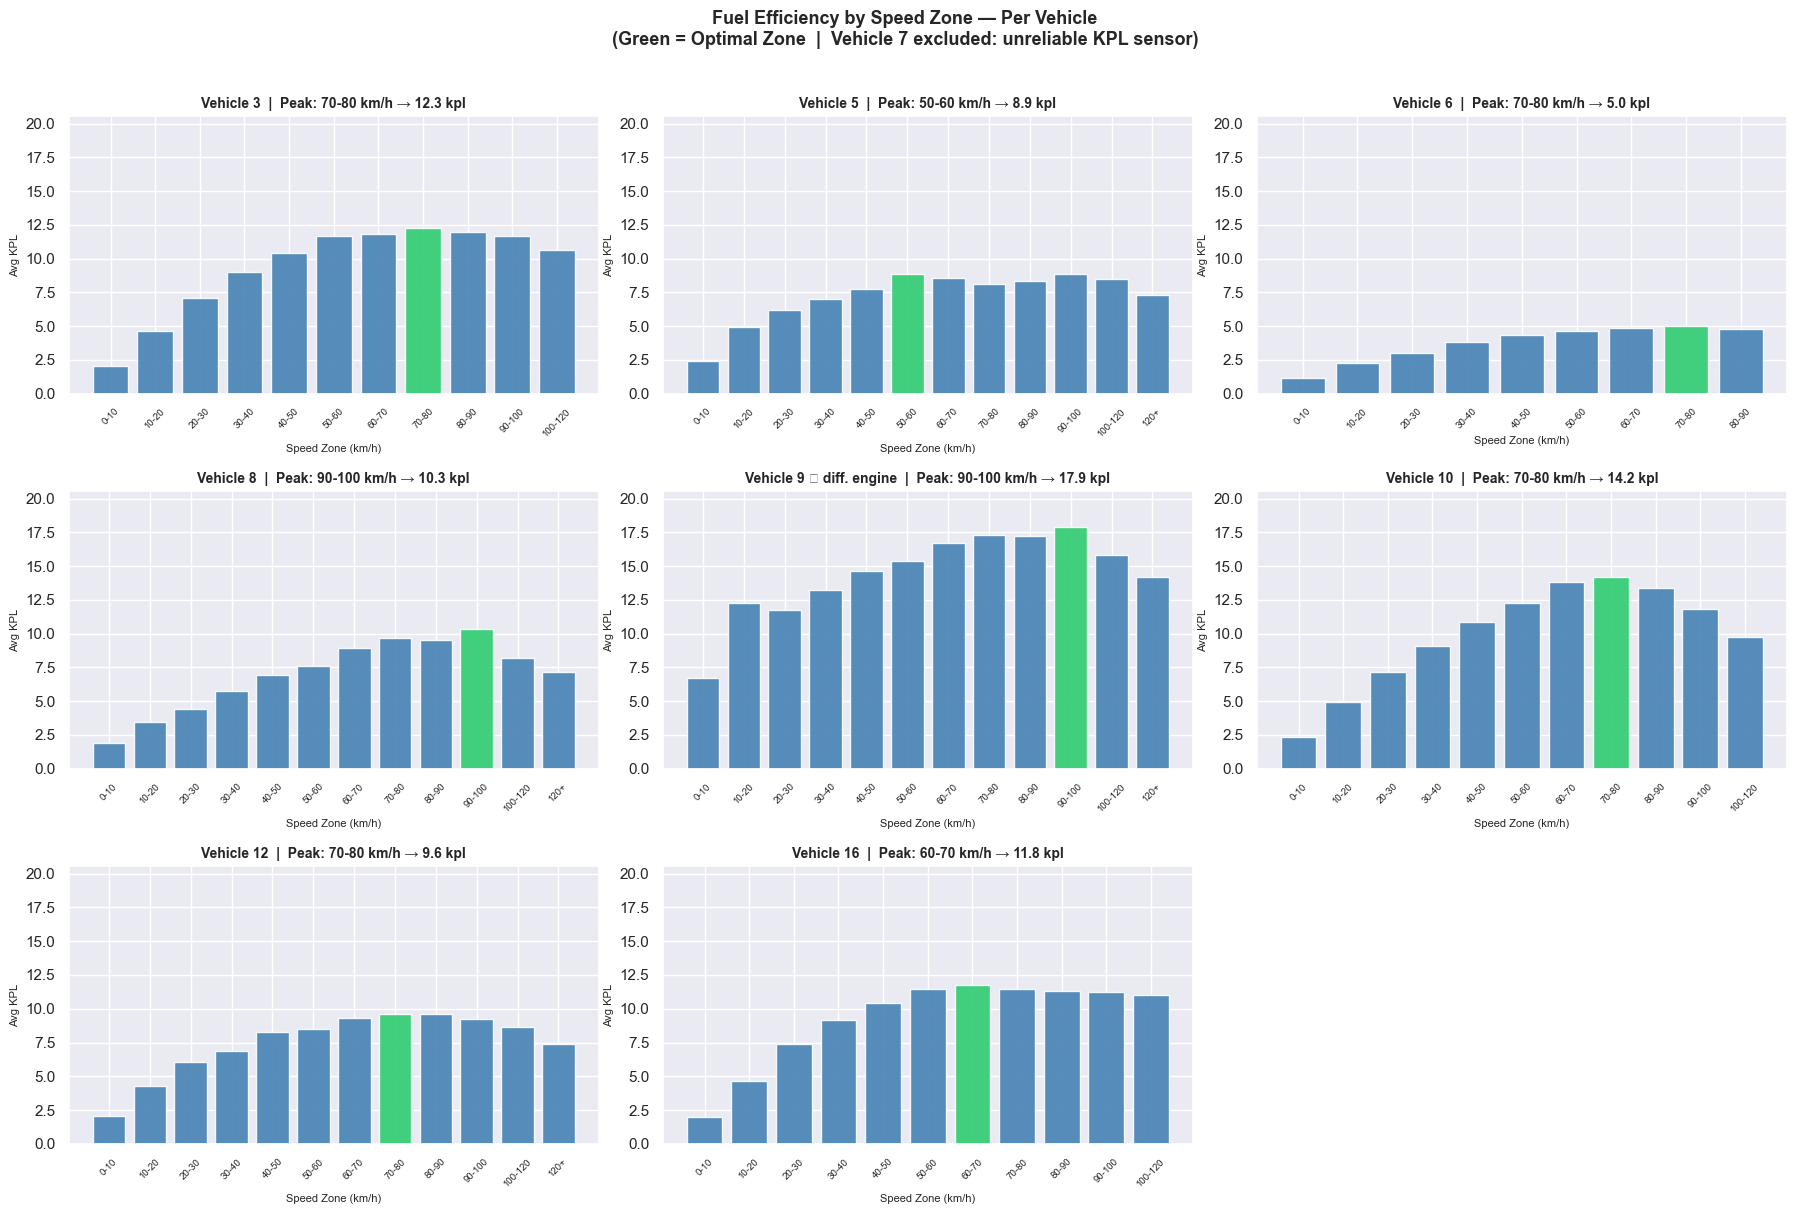

Saved -> outputs/04_speed_efficiency_map.png


In [8]:
speed_map = df_moving.groupby(['deviceID','speed_zone'])['kpl'].agg(
    mean_kpl   = 'mean',
    median_kpl = 'median',
    count      = 'count'
).reset_index()
speed_map = speed_map[speed_map['count'] >= 30]
speed_map['mean_kpl'] = speed_map['mean_kpl'].round(2)

devices = sorted(df_moving['deviceID'].dropna().unique())
n_cols  = 3
n_rows  = -(-len(devices) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, dev_id in enumerate(devices):
    ax       = axes[i]
    dev_data = speed_map[speed_map['deviceID'] == dev_id].copy()
    if dev_data.empty:
        continue

    best_zone = dev_data.loc[dev_data['mean_kpl'].idxmax(), 'speed_zone']
    best_kpl  = dev_data['mean_kpl'].max()
    colors    = ['#2ecc71' if z == best_zone else 'steelblue' for z in dev_data['speed_zone']]
    note      = ' ⚠ diff. engine' if dev_id == 9.0 else ''

    ax.bar(dev_data['speed_zone'], dev_data['mean_kpl'],
           color=colors, edgecolor='white', alpha=0.9)
    ax.set_title(f'Vehicle {int(dev_id)}{note}  |  Peak: {best_zone} km/h → {best_kpl:.1f} kpl',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Speed Zone (km/h)', fontsize=8)
    ax.set_ylabel('Avg KPL', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_ylim(0, speed_map['mean_kpl'].max() * 1.15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Fuel Efficiency by Speed Zone — Per Vehicle\n'
    '(Green = Optimal Zone  |  Vehicle 7 excluded: unreliable KPL sensor)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/04_speed_efficiency_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/04_speed_efficiency_map.png')

## 2. Fleet Heatmap

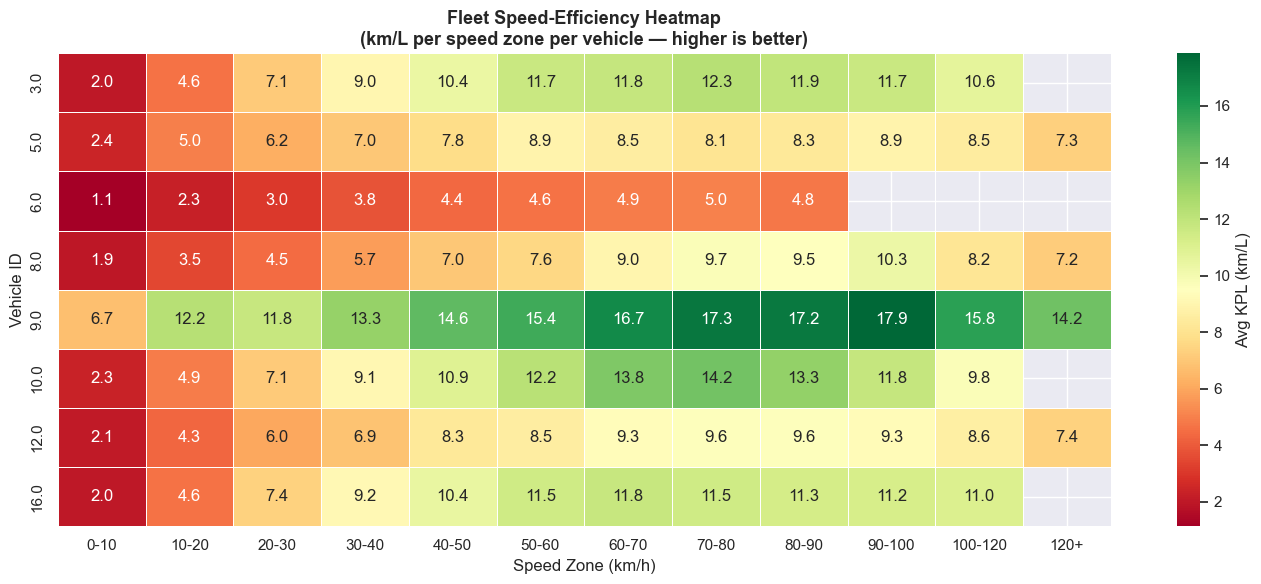

Saved -> outputs/04b_fleet_heatmap.png


In [9]:
heatmap_data = speed_map.pivot_table(
    index='deviceID', columns='speed_zone', values='mean_kpl'
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Avg KPL (km/L)'}
)
plt.title(
    'Fleet Speed-Efficiency Heatmap\n(km/L per speed zone per vehicle — higher is better)',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Speed Zone (km/h)')
plt.ylabel('Vehicle ID')
plt.tight_layout()
plt.savefig('../outputs/04b_fleet_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/04b_fleet_heatmap.png')

## 3. Fleet Fuel Consumption

In [10]:
# Time delta between consecutive readings within each trip
df_moving['time_diff_s'] = (
    df_moving.groupby(['deviceID','tripID'])['timeStamp']
    .diff().dt.total_seconds()
)
df_moving['time_diff_s'] = df_moving['time_diff_s'].clip(0, 5)

# distance (km) = speed (km/h) / 3600 * time (s)
df_moving['dist_km'] = df_moving['speed'] / 3600 * df_moving['time_diff_s']
df_moving['fuel_L']  = df_moving['dist_km'] / df_moving['kpl'].replace(0, np.nan)

trip_summary = df_moving.groupby(['deviceID','tripID']).agg(
    total_dist_km = ('dist_km',     'sum'),
    total_fuel_L  = ('fuel_L',      'sum'),
    avg_kpl       = ('kpl',         'mean'),
    avg_speed     = ('speed',       'mean'),
    max_speed     = ('speed',       'max'),
    avg_rpm       = ('rpm',         'mean'),
    duration_min  = ('time_diff_s', 'sum'),
).reset_index()
trip_summary['duration_min'] = (trip_summary['duration_min'] / 60).round(1)

trip_summary = trip_summary[
    (trip_summary['total_dist_km'] > 0.5) &
    (trip_summary['total_fuel_L']  < 200) &
    (trip_summary['total_fuel_L']  > 0)
].reset_index(drop=True)

fleet_summary = trip_summary.groupby('deviceID').agg(
    total_trips   = ('tripID',        'count'),
    total_dist_km = ('total_dist_km', 'sum'),
    total_fuel_L  = ('total_fuel_L',  'sum'),
    avg_speed     = ('avg_speed',     'mean'),
).reset_index()
fleet_summary['overall_kpl'] = (
    fleet_summary['total_dist_km'] / fleet_summary['total_fuel_L']
).round(2)
fleet_summary = fleet_summary.sort_values('overall_kpl', ascending=False).reset_index(drop=True)

print('Fleet Summary — Ranked by Fuel Efficiency:')
print(fleet_summary.to_string(index=False))

Fleet Summary — Ranked by Fuel Efficiency:
 deviceID  total_trips  total_dist_km  total_fuel_L  avg_speed  overall_kpl
      9.0          147    1509.008333    123.217097  28.375244        12.25
     10.0          352    3470.459167    397.986319  29.267814         8.72
      3.0          123    1287.111389    147.829425  27.866310         8.71
     16.0           38     492.505833     65.800325  23.786737         7.48
     12.0          266    2805.429444    448.879158  24.946310         6.25
      5.0          222    1733.408333    282.078263  29.801431         6.15
      8.0           30     265.458056     55.460099  29.198060         4.79
      6.0           12     121.444444     37.671934  32.959089         3.22


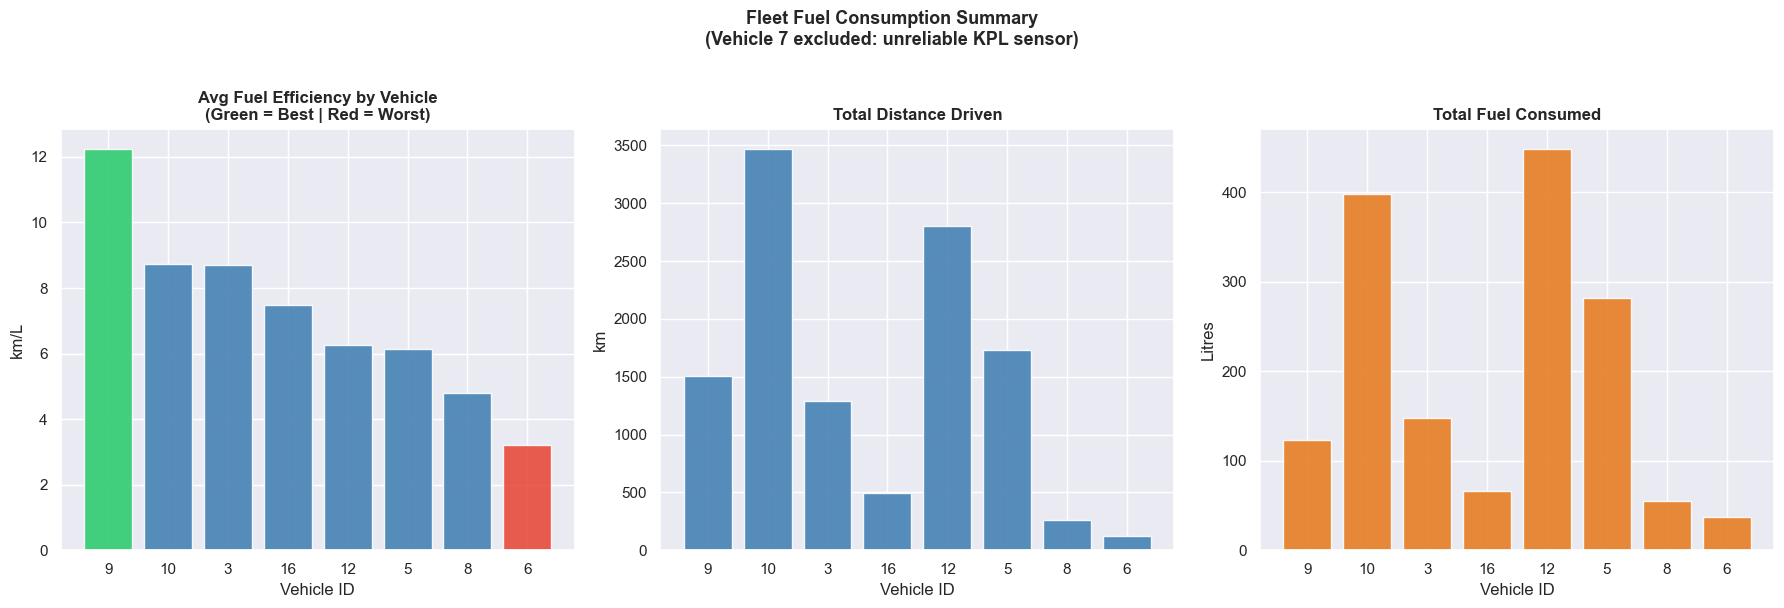

Saved -> outputs/05_fleet_fuel_summary.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vids = fleet_summary['deviceID'].astype(int).astype(str)

colors = [
    '#2ecc71' if v == fleet_summary['overall_kpl'].max()
    else '#e74c3c' if v == fleet_summary['overall_kpl'].min()
    else 'steelblue'
    for v in fleet_summary['overall_kpl']
]
axes[0].bar(vids, fleet_summary['overall_kpl'], color=colors, edgecolor='white', alpha=0.9)
axes[0].set_title('Avg Fuel Efficiency by Vehicle\n(Green = Best | Red = Worst)', fontweight='bold')
axes[0].set_xlabel('Vehicle ID')
axes[0].set_ylabel('km/L')

axes[1].bar(vids, fleet_summary['total_dist_km'], color='steelblue', edgecolor='white', alpha=0.9)
axes[1].set_title('Total Distance Driven', fontweight='bold')
axes[1].set_xlabel('Vehicle ID')
axes[1].set_ylabel('km')

axes[2].bar(vids, fleet_summary['total_fuel_L'], color='#e67e22', edgecolor='white', alpha=0.9)
axes[2].set_title('Total Fuel Consumed', fontweight='bold')
axes[2].set_xlabel('Vehicle ID')
axes[2].set_ylabel('Litres')

plt.suptitle(
    'Fleet Fuel Consumption Summary\n(Vehicle 7 excluded: unreliable KPL sensor)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/05_fleet_fuel_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/05_fleet_fuel_summary.png')

## 4. Export

In [12]:
trip_summary.to_csv('../data/processed/trip_summary.csv', index=False)
fleet_summary.to_csv('../data/processed/fleet_summary.csv', index=False)
speed_map.to_csv('../data/processed/speed_map.csv', index=False)

best    = fleet_summary.iloc[0]
worst   = fleet_summary.iloc[-1]
optimal = speed_map.loc[speed_map.groupby('deviceID')['mean_kpl'].idxmax(), 'speed_zone'].mode()[0]

print('=' * 55)
print('  KEY FINDINGS')
print('=' * 55)
print(f'  Most efficient  : Vehicle {int(best["deviceID"])} → {best["overall_kpl"]:.1f} kpl')
print(f'  Least efficient : Vehicle {int(worst["deviceID"])} → {worst["overall_kpl"]:.1f} kpl')
print(f'  Efficiency gap  : {best["overall_kpl"] - worst["overall_kpl"]:.1f} kpl')
print(f'  Fleet optimal speed zone : {optimal} km/h')
print(f'  Total distance  : {fleet_summary["total_dist_km"].sum():,.0f} km')
print(f'  Total fuel      : {fleet_summary["total_fuel_L"].sum():,.1f} L')
print('=' * 55)

  KEY FINDINGS
  Most efficient  : Vehicle 9 → 12.2 kpl
  Least efficient : Vehicle 6 → 3.2 kpl
  Efficiency gap  : 9.0 kpl
  Fleet optimal speed zone : 70-80 km/h
  Total distance  : 11,685 km
  Total fuel      : 1,558.9 L
